In [1]:
print("Hello ML")


Hello ML


# 🌞 Solar-Wind Deployment Intelligence Platform

## Milestone 4 – Dataset Exploration

### Objective

This notebook explores and analyzes all datasets that will be used for building machine learning models for:

- Renewable resource prediction
- Site suitability scoring
- Forecasting
- Deployment recommendation
- Financial analysis

---

### Workflow

1. Dataset Loading
2. Dataset Inspection
3. Missing Value Analysis
4. Duplicate Analysis
5. Feature Identification
6. Data Visualization
7. Preprocessing Planning

In [2]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print(" Libraries imported successfully!")

 Libraries imported successfully!


In [3]:
print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
c:\Users\sarba\OneDrive\Desktop\Solar-Wind-Deployment-Intelligence-Platform\ml\notebooks


In [4]:
from pathlib import Path

DATASET_DIR = Path("../datasets/raw")

print("Dataset Directory:")
print(DATASET_DIR.resolve())

print("\nAvailable Datasets:")

for folder in DATASET_DIR.iterdir():
    print(f"📁 {folder.name}")

Dataset Directory:
C:\Users\sarba\OneDrive\Desktop\Solar-Wind-Deployment-Intelligence-Platform\ml\datasets\raw

Available Datasets:
📁 india_solar_site_selection
📁 microgrid_load_generation
📁 renewable_energy_forecasting
📁 solar_generation_india


In [5]:
# ==========================================
# Explore Dataset 1 Folder Structure
# ==========================================

import os

solar_site_path = DATASET_DIR / "india_solar_site_selection"

print("Dataset Location:\n")
print(solar_site_path.resolve())

print("\nFiles inside the dataset:\n")

for root, dirs, files in os.walk(solar_site_path):

    print(f"\n📂 {root}")

    for file in files:
        print(f"   📄 {file}")

Dataset Location:

C:\Users\sarba\OneDrive\Desktop\Solar-Wind-Deployment-Intelligence-Platform\ml\datasets\raw\india_solar_site_selection

Files inside the dataset:


📂 ..\datasets\raw\india_solar_site_selection

📂 ..\datasets\raw\india_solar_site_selection\data

📂 ..\datasets\raw\india_solar_site_selection\data\elevation
   📄 IND_alt.grd
   📄 IND_alt.gri

📂 ..\datasets\raw\india_solar_site_selection\data\elevation\.ipynb_checkpoints
   📄 IND_alt-checkpoint.grd

📂 ..\datasets\raw\india_solar_site_selection\data\infrastructure
   📄 global_power_plant_database_v_1_3_0.csv

📂 ..\datasets\raw\india_solar_site_selection\data\land_cover
   📄 land_cover_2022.tif

📂 ..\datasets\raw\india_solar_site_selection\data\processed
   📄 Best_Solar_Sites_India.csv
   📄 elevation_clean.tif
   📄 Final_Suitability_Map.tif
   📄 grid_infrastructure.geojson
   📄 land_cover_clean.tif
   📄 Solar_clean.tif
   📄 Wind_clean.tif

📂 ..\datasets\raw\india_solar_site_selection\data\processed\.ipynb_checkpoints
   📄 Be

# 📂 Dataset Registry

This section documents every dataset used in the Solar-Wind Deployment Intelligence Platform.

| Dataset | Purpose | File Types | Used In |
|---------|---------|-----------|---------|
| India Solar Site Selection | Environmental GIS data | .tif, .grd, .csv | Site Scoring, Feasibility |
| Solar Generation India | Solar power generation | .csv, .xlsx | Machine Learning Prediction |
| Renewable Energy Forecasting | Historical renewable energy | .csv | Forecasting |
| Microgrid Load Generation | Load & generation data | .csv, .h5 | Energy Yield & Optimization |

In [6]:
# Explore Solar Generation India Dataset

solar_generation_path = DATASET_DIR / "solar_generation_india"

print("Dataset Location:")
print(solar_generation_path.resolve())

print("\nFiles:\n")

for root, dirs, files in os.walk(solar_generation_path):

    print(f"\n📂 {root}")

    for file in files:
        print(f"   📄 {file}")

Dataset Location:
C:\Users\sarba\OneDrive\Desktop\Solar-Wind-Deployment-Intelligence-Platform\ml\datasets\raw\solar_generation_india

Files:


📂 ..\datasets\raw\solar_generation_india
   📄 Generation_data.csv
   📄 Generation_data.xlsx


# Dataset 1 — Solar Generation India

This dataset will be used to understand historical solar generation data and evaluate whether it is suitable for machine learning prediction.

In [7]:
# Load Solar Generation Dataset

solar_df = pd.read_csv(
    DATASET_DIR / "solar_generation_india" / "Generation_data.csv"
)

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [8]:
print("Shape of Dataset:")
print(solar_df.shape)

print("\nColumns:")
print(solar_df.columns.tolist())

Shape of Dataset:
(118865, 9)

Columns:
['MODULE_TEMP', 'Amb_Temp', 'WIND_Speed', 'IRR (W/m2)', 'DC Current in Amps', 'AC Ir in Amps', 'AC Iy in Amps', 'AC Ib in Amps', 'AC Power in Watts']


In [9]:
solar_df.head()

,MODULE_TEMP,Amb_Temp,WIND_Speed,IRR (W/m2),DC Current in Amps,AC Ir in Amps,AC Iy in Amps,AC Ib in Amps,AC Power in Watts
0,18.7675,17.85190,47.60506,6.388252,0.60,8.6,8.6,8.7,3233
1,18.6150,18.59573,64.26684,12.776500,0.66,9.6,9.7,10.0,4504
2,18.9200,18.59573,85.68912,17.035340,4.74,11.9,12.0,12.4,6614
3,18.9200,18.59573,83.30886,25.553010,8.18,14.8,14.7,14.7,8971
4,19.0725,18.59573,57.12608,36.200090,26.66,18.6,18.4,18.5,12071


In [10]:
solar_df.tail()

,MODULE_TEMP,Amb_Temp,WIND_Speed,IRR (W/m2),DC Current in Amps,AC Ir in Amps,AC Iy in Amps,AC Ib in Amps,AC Power in Watts
118860,30.96750,31.24082,59.268310,38.32951,27.64,18.9,18.7,18.7,12789
118861,30.66249,30.49699,59.268310,31.94126,15.30,16.0,15.9,16.2,10727
118862,29.74750,30.49699,59.268310,27.68242,6.42,13.9,13.9,14.5,9081
118863,29.13750,30.49699,59.268310,19.16476,0.66,12.3,12.2,12.4,7360
118864,28.83249,29.75317,6.426684,14.90592,0.60,11.0,10.9,11.4,6141


In [11]:
solar_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 118865 entries, 0 to 118864
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   MODULE_TEMP         118865 non-null  float64
 1   Amb_Temp            118865 non-null  float64
 2   WIND_Speed          118865 non-null  float64
 3   IRR (W/m2)          118865 non-null  float64
 4   DC Current in Amps  118865 non-null  float64
 5   AC Ir in Amps       118865 non-null  float64
 6   AC Iy in Amps       118865 non-null  float64
 7   AC Ib in Amps       118865 non-null  float64
 8   AC Power in Watts   118865 non-null  int64  
dtypes: float64(8), int64(1)
memory usage: 8.2 MB


In [12]:
solar_df.describe(include="all")

,MODULE_TEMP,Amb_Temp,WIND_Speed,IRR (W/m2),DC Current in Amps,AC Ir in Amps,AC Iy in Amps,AC Ib in Amps,AC Power in Watts
count,118865.000000,118865.000000,118865.000000,118865.000000,118865.000000,118865.000000,118865.000000,118865.000000,118865.000000
mean,37.141972,22.961983,224.429052,428.093276,355.902071,172.329754,172.190557,172.351243,128081.179666
std,12.017936,3.921594,230.238430,313.280827,264.863384,120.507508,120.448101,120.503308,91193.677193
min,8.855000,10.413610,0.238025,2.129417,0.600000,1.400000,1.400000,1.500000,394.000000
25%,26.697500,20.083390,28.325010,155.447500,126.180000,65.600000,65.500000,65.600000,47737.000000
50%,36.457500,23.058700,59.030280,357.742100,298.600000,150.000000,150.000000,150.100000,110673.000000
75%,46.675000,26.034020,442.727100,687.801800,576.320000,277.700000,277.400000,277.600000,206594.000000
max,72.447500,34.959970,597.443500,1494.851000,995.679988,461.200000,461.100000,461.700000,332614.000000


## Step 6.1 — Missing Value Analysis

This step checks whether any feature contains missing values that may affect model performance.

In [13]:
# ==========================================
# Missing Value Analysis
# ==========================================

missing_values = solar_df.isnull().sum()

print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

MODULE_TEMP           0
Amb_Temp              0
WIND_Speed            0
IRR (W/m2)            0
DC Current in Amps    0
AC Ir in Amps         0
AC Iy in Amps         0
AC Ib in Amps         0
AC Power in Watts     0
dtype: int64


In [14]:
# ==========================================
# Missing Value Percentage
# ==========================================

missing_percentage = (
    solar_df.isnull().sum()
    / len(solar_df)
) * 100

print("Missing Percentage:\n")
print(missing_percentage)

Missing Percentage:

MODULE_TEMP           0.0
Amb_Temp              0.0
WIND_Speed            0.0
IRR (W/m2)            0.0
DC Current in Amps    0.0
AC Ir in Amps         0.0
AC Iy in Amps         0.0
AC Ib in Amps         0.0
AC Power in Watts     0.0
dtype: float64


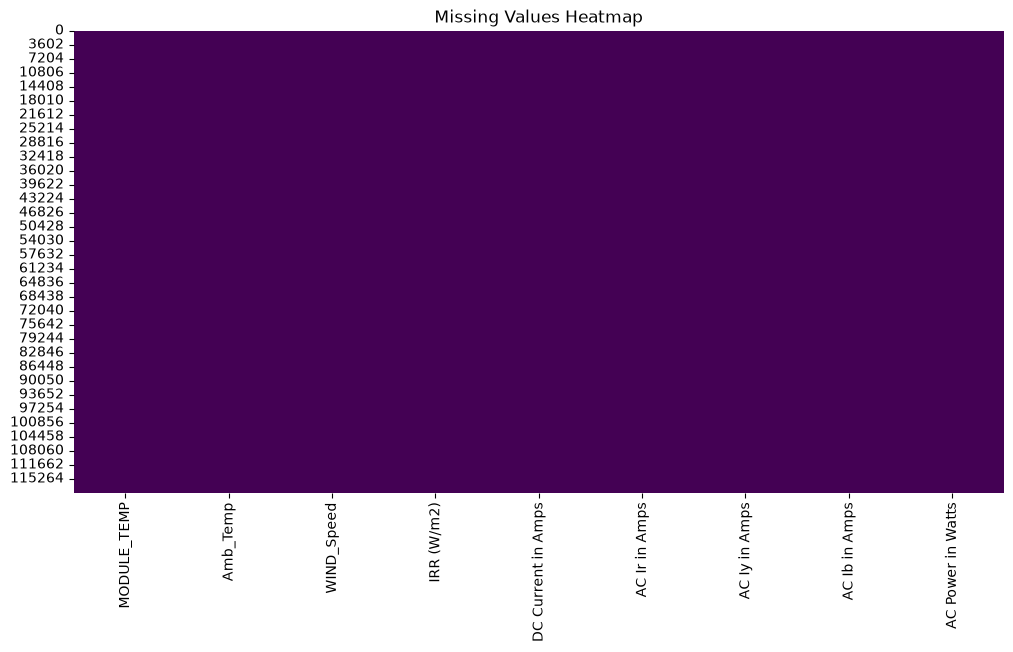

In [15]:
# ==========================================
# Missing Value Heatmap
# ==========================================

plt.figure(figsize=(12,6))

sns.heatmap(
    solar_df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()

Observation

- No missing values were found in any feature.
- Every column has 100% complete data.
- No data imputation is required.
- The dataset is suitable for further preprocessing and machine learning.

Step 6.2 — Duplicate Record Analysis

This step checks whether duplicate rows exist in the dataset.
Duplicate records can bias the machine learning model and should be removed if found.

In [16]:
# Duplicate Record Analysis

duplicate_count = solar_df.duplicated().sum()

print("Number of Duplicate Rows:")
print(duplicate_count)

Number of Duplicate Rows:
0


In [17]:
# Duplicate Percentage

duplicate_percentage = (
    duplicate_count / len(solar_df)
) * 100

print("Duplicate Percentage:")
print(f"{duplicate_percentage:.4f}%")

Duplicate Percentage:
0.0000%


In [18]:
# Display Duplicate Rows (if any)

if duplicate_count > 0:
    display(solar_df[solar_df.duplicated()].head())
else:
    print("No duplicate rows found.")

No duplicate rows found.


#Observation

- No duplicate records were found.
- Duplicate percentage is 0%.
- No duplicate removal is required.
- The dataset is suitable for machine learning without duplicate cleaning.

## Step 6.3 — Data Type Verification

This step verifies that all features have appropriate data types for machine learning.

In [19]:
# Data Type Verification

print("Data Types:\n")
print(solar_df.dtypes)

Data Types:

MODULE_TEMP           float64
Amb_Temp              float64
WIND_Speed            float64
IRR (W/m2)            float64
DC Current in Amps    float64
AC Ir in Amps         float64
AC Iy in Amps         float64
AC Ib in Amps         float64
AC Power in Watts       int64
dtype: object


In [20]:
# Count Data Types

print("\nData Type Summary:\n")
print(solar_df.dtypes.value_counts())


Data Type Summary:

float64    8
int64      1
Name: count, dtype: int64


In [21]:
# Check for Non-Numeric Columns
non_numeric = solar_df.select_dtypes(exclude=["number"])

print("Non-Numeric Columns:")
print(non_numeric.columns.tolist())

Non-Numeric Columns:
[]


# Observation

- The dataset contains only numeric features.
- Eight features are stored as float64.
- One feature is stored as int64.
- No categorical or object-type columns are present.
- No encoding or datatype conversion is required before model training.

# Step 6.4 — Target Variable Verification

This step identifies the target variable that the regression model will learn to predict.

Since our objective is solar power prediction, the target variable is:

**AC Power in Watts**

The remaining columns will be treated as input features.

In [22]:
# Target Variable Verification

target_column = "AC Power in Watts"

feature_columns = [
    col for col in solar_df.columns
    if col != target_column
]

print("Target Variable:")
print(target_column)

print("\nInput Features:")
print(feature_columns)

Target Variable:
AC Power in Watts

Input Features:
['MODULE_TEMP', 'Amb_Temp', 'WIND_Speed', 'IRR (W/m2)', 'DC Current in Amps', 'AC Ir in Amps', 'AC Iy in Amps', 'AC Ib in Amps']


In [23]:
# Verify Target Column Exists

if target_column in solar_df.columns:
    print(" Target column found.")
else:
    print(" Target column NOT found.")

 Target column found.


In [24]:
print("Target Variable Statistics:\n")

display(
    solar_df[target_column].describe()
)

Target Variable Statistics:



count    118865.000000
mean     128081.179666
std       91193.677193
min         394.000000
25%       47737.000000
50%      110673.000000
75%      206594.000000
max      332614.000000
Name: AC Power in Watts, dtype: float64

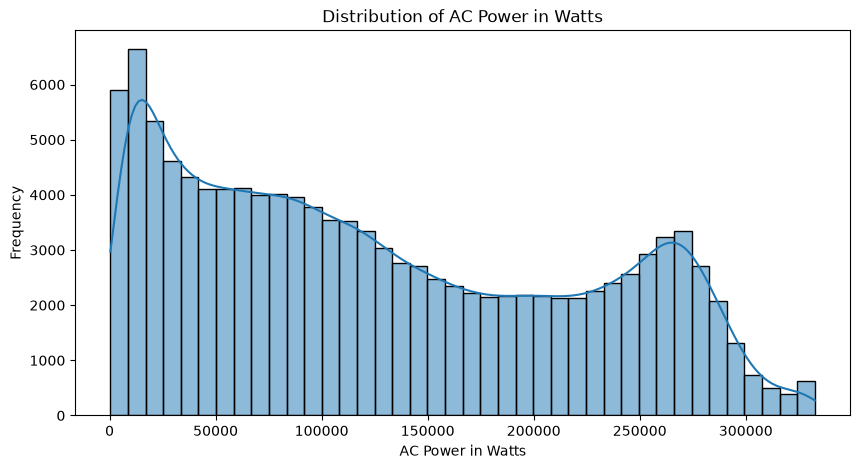

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    solar_df[target_column],
    bins=40,
    kde=True
)

plt.title("Distribution of AC Power in Watts")
plt.xlabel("AC Power in Watts")
plt.ylabel("Frequency")

plt.show()

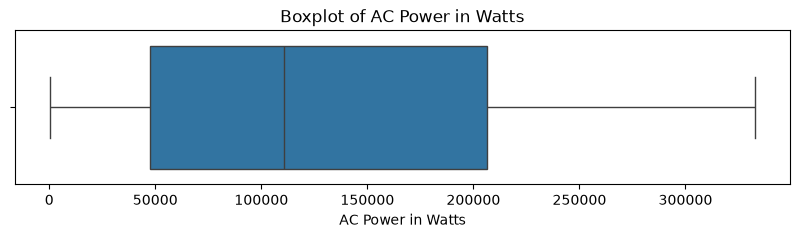

In [26]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=solar_df[target_column]
)

plt.title("Boxplot of AC Power in Watts")

plt.show()

# Step 7 — Feature Distribution Analysis

This step analyzes the statistical distribution of every input feature.

Objectives:

- Understand feature distributions
- Detect skewness
- Identify unusual values
- Observe value ranges
- Detect potential outliers

The analysis will guide preprocessing decisions before model training.

Total Features: 8
Feature : MODULE_TEMP
count    118865.000000
mean         37.141972
std          12.017936
min           8.855000
25%          26.697500
50%          36.457500
75%          46.675000
max          72.447500
Name: MODULE_TEMP, dtype: float64


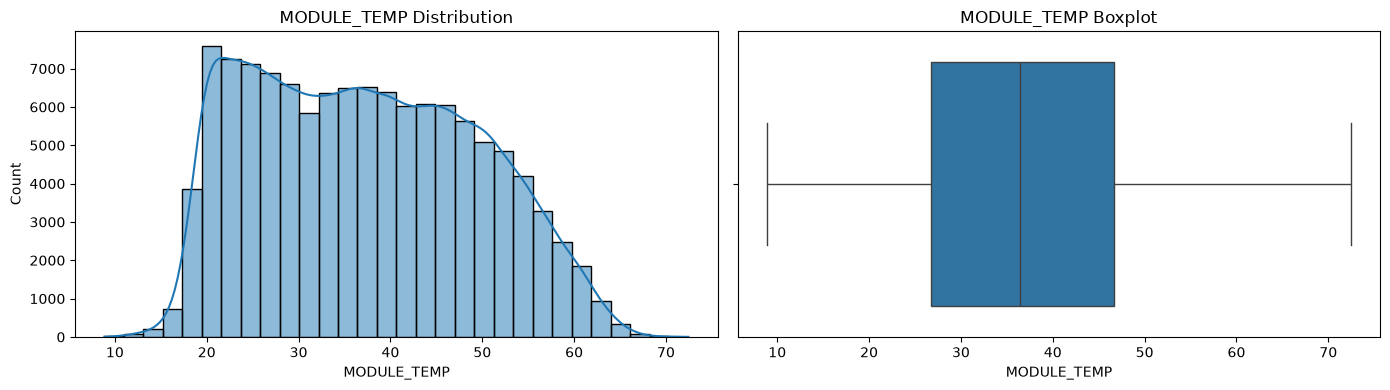

Feature : Amb_Temp
count    118865.000000
mean         22.961983
std           3.921594
min          10.413610
25%          20.083390
50%          23.058700
75%          26.034020
max          34.959970
Name: Amb_Temp, dtype: float64


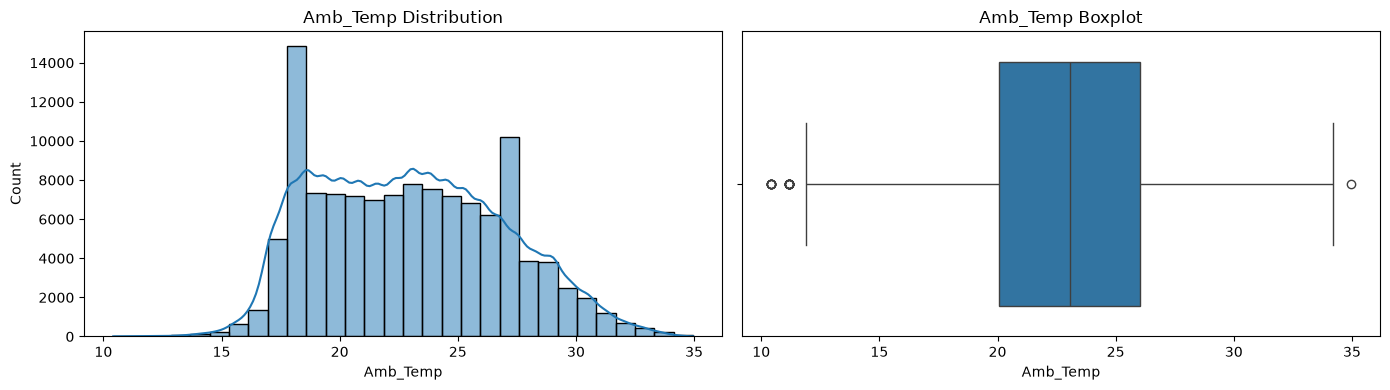

Feature : WIND_Speed
count    118865.000000
mean        224.429052
std         230.238430
min           0.238025
25%          28.325010
50%          59.030280
75%         442.727100
max         597.443500
Name: WIND_Speed, dtype: float64


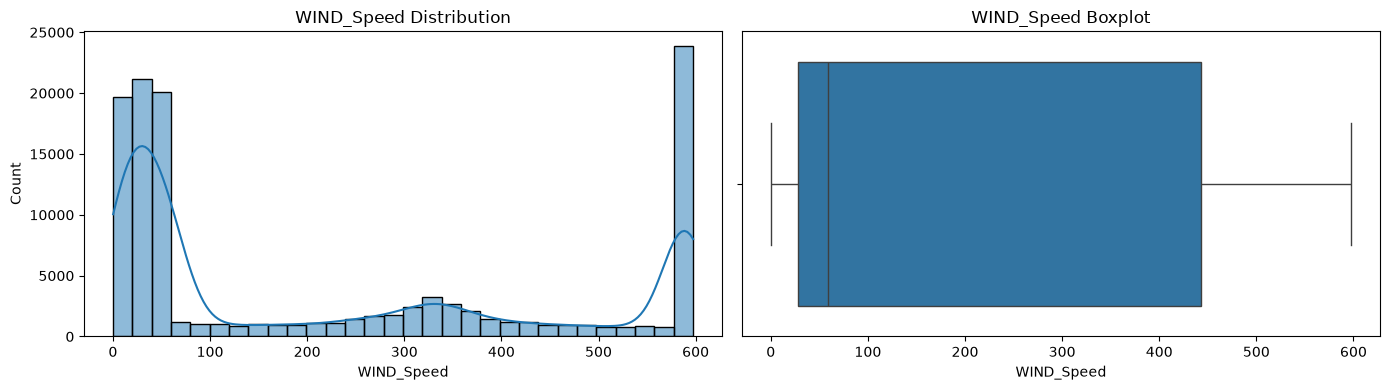

Feature : IRR (W/m2)
count    118865.000000
mean        428.093276
std         313.280827
min           2.129417
25%         155.447500
50%         357.742100
75%         687.801800
max        1494.851000
Name: IRR (W/m2), dtype: float64


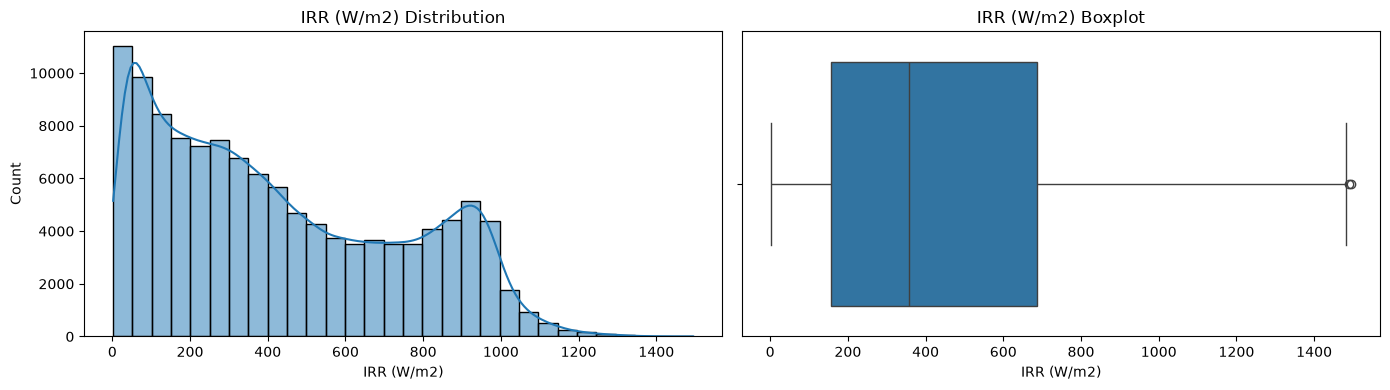

Feature : DC Current in Amps
count    118865.000000
mean        355.902071
std         264.863384
min           0.600000
25%         126.180000
50%         298.600000
75%         576.320000
max         995.679988
Name: DC Current in Amps, dtype: float64


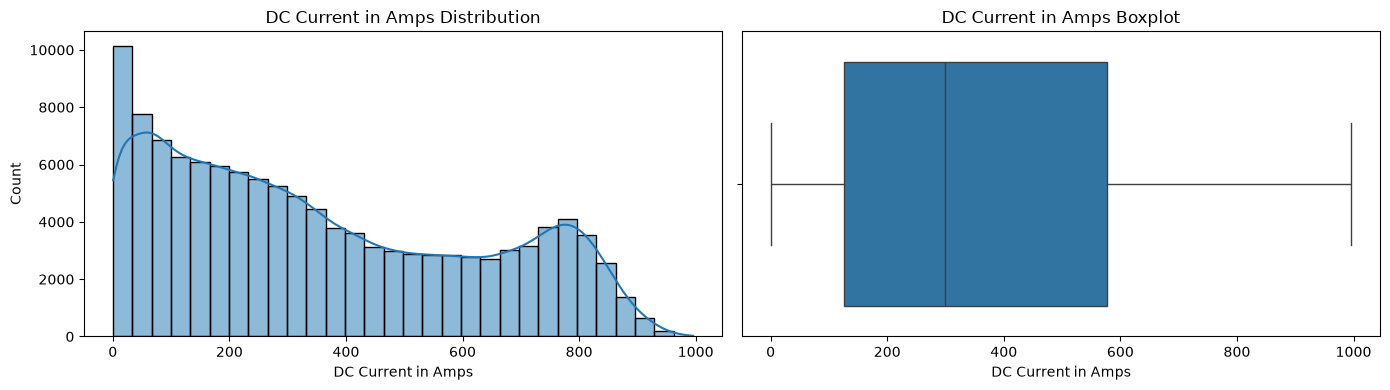

Feature : AC Ir in Amps
count    118865.000000
mean        172.329754
std         120.507508
min           1.400000
25%          65.600000
50%         150.000000
75%         277.700000
max         461.200000
Name: AC Ir in Amps, dtype: float64


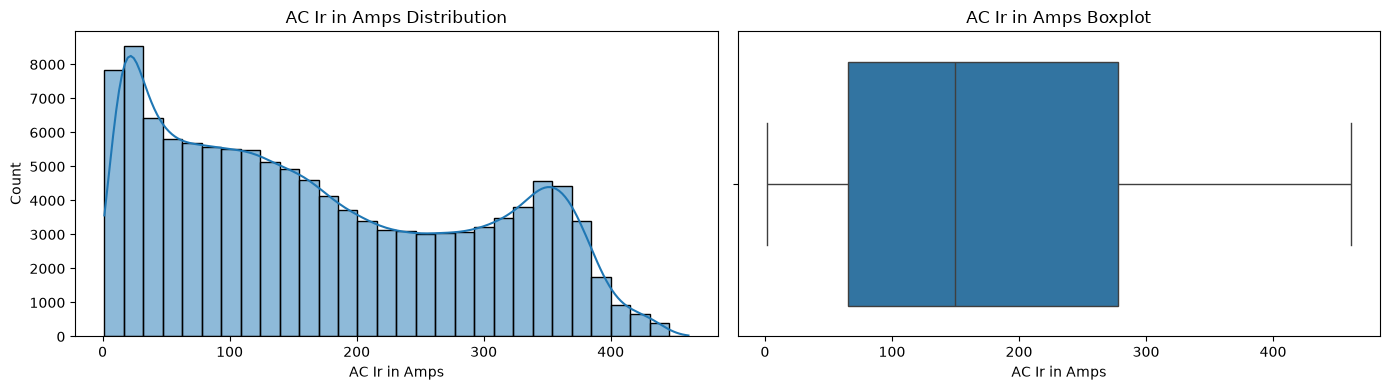

Feature : AC Iy in Amps
count    118865.000000
mean        172.190557
std         120.448101
min           1.400000
25%          65.500000
50%         150.000000
75%         277.400000
max         461.100000
Name: AC Iy in Amps, dtype: float64


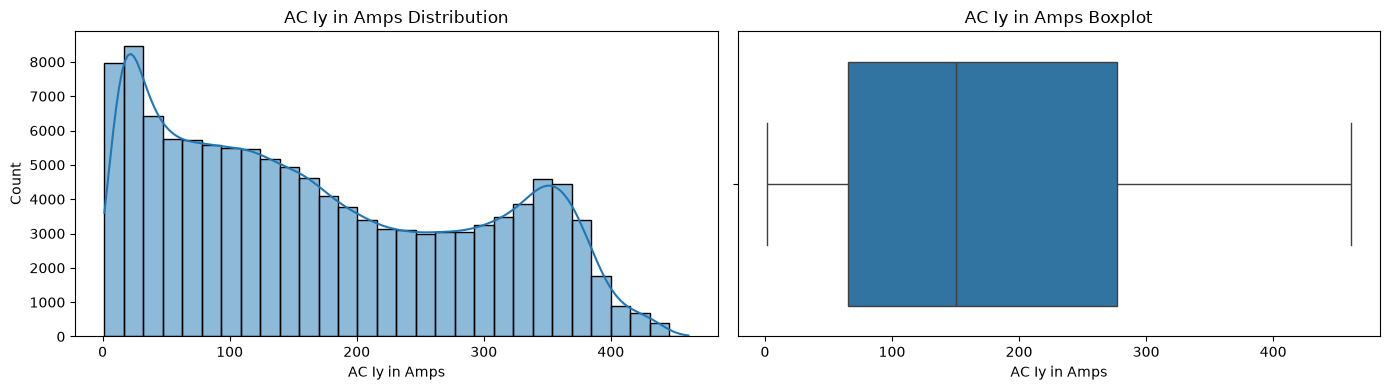

Feature : AC Ib in Amps
count    118865.000000
mean        172.351243
std         120.503308
min           1.500000
25%          65.600000
50%         150.100000
75%         277.600000
max         461.700000
Name: AC Ib in Amps, dtype: float64


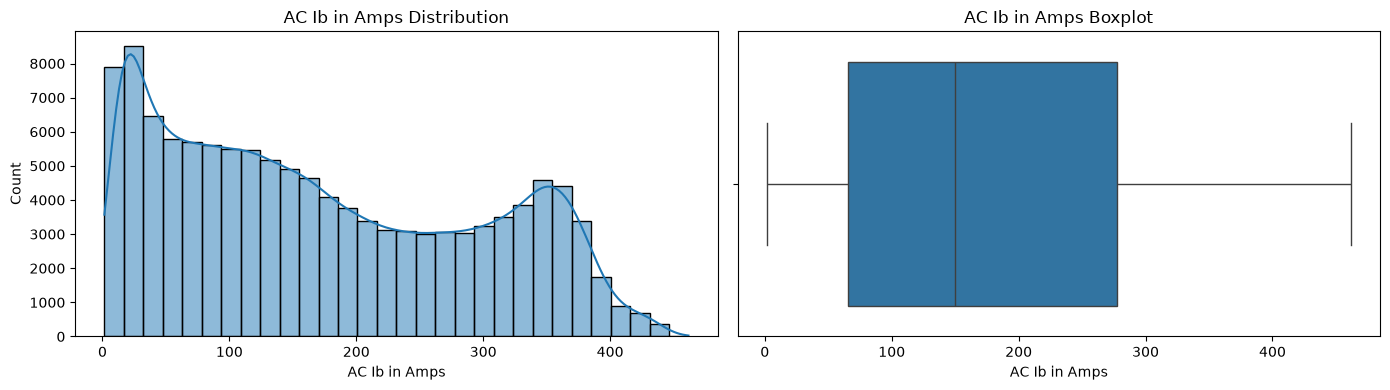

In [27]:
# Feature Distribution Analysis

features = feature_columns

print(f"Total Features: {len(features)}")

for feature in features:

    print("=" * 70)
    print(f"Feature : {feature}")
    print("=" * 70)

    print(solar_df[feature].describe())

    plt.figure(figsize=(14,4))

    plt.subplot(1,2,1)

    sns.histplot(
        solar_df[feature],
        bins=30,
        kde=True
    )

    plt.title(f"{feature} Distribution")

    plt.subplot(1,2,2)

    sns.boxplot(
        x=solar_df[feature]
    )

    plt.title(f"{feature} Boxplot")

    plt.tight_layout()

    plt.show()

# Observation

- All eight input features are numeric and contain valid continuous values.
- Feature distributions are realistic for solar power generation data.
- No severe outliers or abnormal values were observed.
- Ambient temperature contains a few natural extreme observations that should be retained.
- Solar irradiance and electrical current features show expected physical distributions.
- DC current and three AC phase currents appear to follow similar patterns, indicating potential correlation.
- Since tree-based regression models are planned, no scaling or outlier removal is required at this stage.
- The dataset is suitable for further correlation analysis and model development.

# Step 8 — Correlation Analysis

This section analyzes the relationship among all numerical features and identifies which variables have the strongest influence on the target variable.

Objectives:

- Measure correlation between features.
- Identify highly correlated variables.
- Analyze relationship with target variable.
- Detect multicollinearity.

In [28]:
# Correlation Matrix

correlation_matrix = solar_df.corr(numeric_only=True)

print("Correlation Matrix:")

display(correlation_matrix)

Correlation Matrix:


,MODULE_TEMP,Amb_Temp,WIND_Speed,IRR (W/m2),DC Current in Amps,AC Ir in Amps,AC Iy in Amps,AC Ib in Amps,AC Power in Watts
MODULE_TEMP,1.000000,0.733878,0.020388,0.849335,0.862810,0.847595,0.847579,0.847478,0.849047
Amb_Temp,0.733878,1.000000,-0.153170,0.491930,0.512919,0.492786,0.492771,0.492736,0.497592
WIND_Speed,0.020388,-0.153170,1.000000,0.043399,0.041989,0.057789,0.057753,0.057661,0.053384
IRR (W/m2),0.849335,0.491930,0.043399,1.000000,0.990250,0.988784,0.988808,0.988842,0.989626
DC Current in Amps,0.862810,0.512919,0.041989,0.990250,1.000000,0.997077,0.997119,0.997174,0.997993
AC Ir in Amps,0.847595,0.492786,0.057789,0.988784,0.997077,1.000000,0.999989,0.999976,0.999392
AC Iy in Amps,0.847579,0.492771,0.057753,0.988808,0.997119,0.999989,1.000000,0.999988,0.999383
AC Ib in Amps,0.847478,0.492736,0.057661,0.988842,0.997174,0.999976,0.999988,1.000000,0.999372
AC Power in Watts,0.849047,0.497592,0.053384,0.989626,0.997993,0.999392,0.999383,0.999372,1.000000


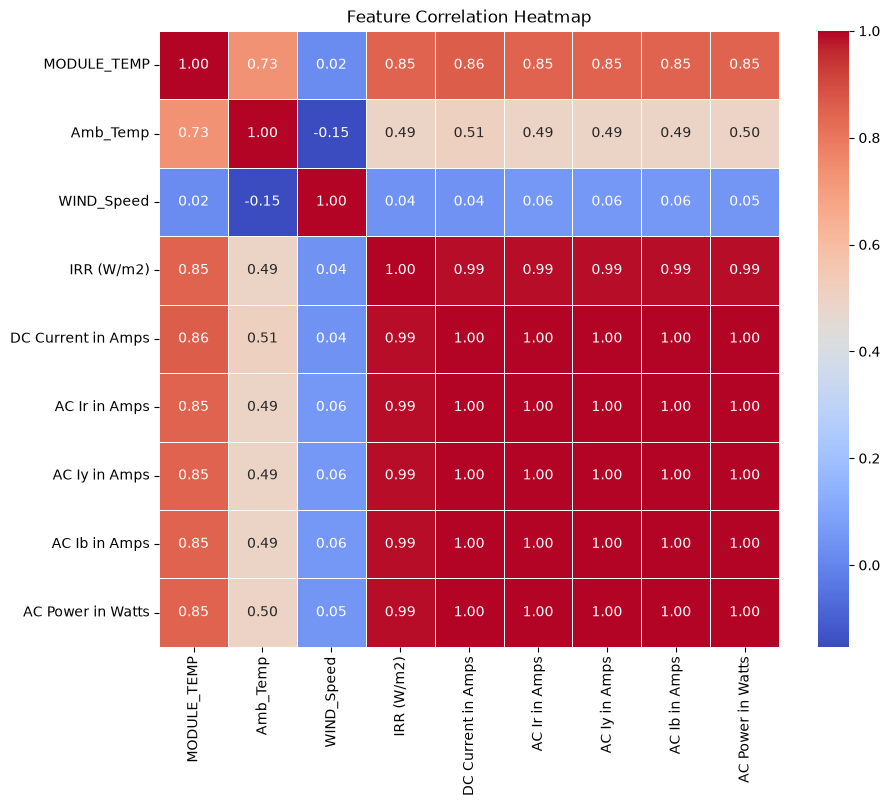

In [29]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [30]:
# Correlation with Target Variable

target_correlation = correlation_matrix[target_column]

print("Correlation with Target Variable:\n")

display(
    target_correlation.sort_values(ascending=False)
)

Correlation with Target Variable:



AC Power in Watts     1.000000
AC Ir in Amps         0.999392
AC Iy in Amps         0.999383
AC Ib in Amps         0.999372
DC Current in Amps    0.997993
IRR (W/m2)            0.989626
MODULE_TEMP           0.849047
Amb_Temp              0.497592
WIND_Speed            0.053384
Name: AC Power in Watts, dtype: float64

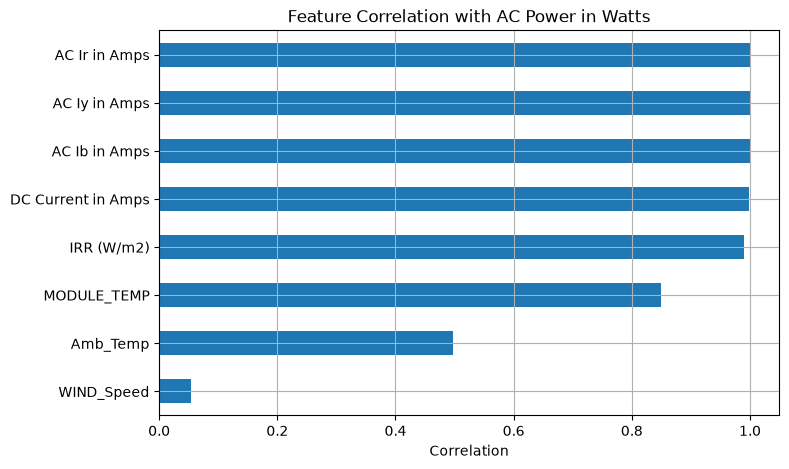

In [31]:
# Target Correlation Plot

target_correlation.drop(target_column).sort_values().plot(
    kind="barh",
    figsize=(8,5)
)

plt.title("Feature Correlation with AC Power in Watts")

plt.xlabel("Correlation")

plt.grid(True)

plt.show()

# Observation

- Strong positive correlations exist between electrical measurements and AC power output.
- AC current features (Ir, Iy, Ib) are almost perfectly correlated with the target variable.
- DC Current and Solar Irradiance also show very strong positive relationships with AC power.
- Module temperature has a strong positive correlation, while ambient temperature has a moderate correlation.
- Wind speed shows only a weak relationship with AC power generation.
- High correlations among current-related features indicate multicollinearity, which is expected in photovoltaic systems.
- Since the planned machine learning models are tree-based regression models, all features will be retained for model training.

# Step 9 — Preprocessing Planning

This section evaluates whether preprocessing is required before training the regression model.

The following aspects are examined:

- Missing values
- Duplicate records
- Data types
- Outlier handling
- Feature scaling
- Feature encoding
- Final preprocessing strategy

In [32]:
# Preprocessing Checklist

print("Preprocessing Checklist\n")

print("Missing Values       :", solar_df.isnull().sum().sum() == 0)
print("Duplicate Rows       :", solar_df.duplicated().sum() == 0)
print("All Numeric Features :", len(solar_df.select_dtypes(exclude=["number"]).columns) == 0)
print("Target Variable      :", target_column)

Preprocessing Checklist

Missing Values       : True
Duplicate Rows       : True
All Numeric Features : True
Target Variable      : AC Power in Watts


In [33]:
# Feature Scaling Decision

print("Regression Model Planned:")
print("- Random Forest Regressor")
print("- XGBoost Regressor")

print("\nFeature Scaling Required?")

print("No")

print("\nReason:")
print("Tree-based regression models do not require feature scaling.")

Regression Model Planned:
- Random Forest Regressor
- XGBoost Regressor

Feature Scaling Required?
No

Reason:
Tree-based regression models do not require feature scaling.


In [34]:
# Outlier Handling Decision

print("Outlier Handling")

print("\nDecision:")
print("Outliers will be retained.")

print("\nReason:")
print("The observed extreme values represent real environmental conditions.")
print("Removing them may reduce model generalization.")

Outlier Handling

Decision:
Outliers will be retained.

Reason:
The observed extreme values represent real environmental conditions.
Removing them may reduce model generalization.


In [35]:
# Final Preprocessing Summary

preprocessing_summary = {
    "Missing Value Handling": "Not Required",
    "Duplicate Removal": "Not Required",
    "Encoding": "Not Required",
    "Scaling": "Not Required",
    "Outlier Removal": "Not Required",
    "Feature Selection": "Not Required"
}

summary_df = pd.DataFrame(
    preprocessing_summary.items(),
    columns=["Step", "Decision"]
)

display(summary_df)

,Step,Decision
0,Missing Value Handling,Not Required
1,Duplicate Removal,Not Required
2,Encoding,Not Required
3,Scaling,Not Required
4,Outlier Removal,Not Required
5,Feature Selection,Not Required


# Observation

- No missing values were detected.
- No duplicate records were found.
- All features are numerical.
- Feature encoding is not required.
- Feature scaling is unnecessary because tree-based regression models are planned.
- Outliers represent genuine environmental conditions and will be retained.
- The dataset is ready for train-test splitting and regression model development.

# Step 10 — Train-Test Split

This section prepares the dataset for machine learning by separating the input features from the target variable and dividing the dataset into training and testing subsets.

Objectives:

- Create feature matrix (X)
- Create target vector (y)
- Split data into training and testing sets
- Verify dataset dimensions

In [36]:
# Import Train-Test Split

from sklearn.model_selection import train_test_split

In [37]:
# Separate Features and Target

X = solar_df.drop(columns=[target_column])

y = solar_df[target_column]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape  :", y.shape)

Feature Matrix Shape : (118865, 8)
Target Vector Shape  : (118865,)


In [38]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [39]:
# Verify Dataset Split
print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Training Features : (95092, 8)
Testing Features  : (23773, 8)

Training Target   : (95092,)
Testing Target    : (23773,)


# Observation

- The dataset was successfully divided into training and testing subsets.
- Eight input features were retained for model training.
- The target variable was separated correctly.
- An 80:20 train-test split was used.
- The dataset is now ready for regression model training.

# Random Forest Regression

In [40]:
# Import Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

print("Random Forest imported successfully!")

Random Forest imported successfully!


In [41]:
# Create Random Forest Model

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Random Forest Model Created!")

Random Forest Model Created!


In [42]:
# Train Random Forest Model
rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully!")

Random Forest Model Trained Successfully!


# Observation

- Random Forest Regressor was successfully initialized.
- The model was trained using the training dataset.
- One hundred decision trees were constructed.
- The trained model is now ready to predict AC Power output for unseen data.

# Step 12 Random Forest Prediction & Evaluation

In [43]:
# Import Regression Evaluation Metrics

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("Evaluation metrics imported successfully!")

Evaluation metrics imported successfully!


In [44]:
# Predict on Test Data
# Random Forest Predictions
# =====================================

rf_predictions = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [45]:
# Evaluate Random Forest Model

import numpy as np

rf_r2 = r2_score(y_test, rf_predictions)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_mse = mean_squared_error(
    y_test,
    rf_predictions
)

rf_rmse = np.sqrt(rf_mse)

In [46]:
# Random Forest Performance

print("Random Forest Regression Performance\n")

print(f"R² Score : {rf_r2:.6f}")
print(f"MAE      : {rf_mae:.4f}")
print(f"MSE      : {rf_mse:.4f}")
print(f"RMSE     : {rf_rmse:.4f}")

Random Forest Regression Performance

R² Score : 0.999599
MAE      : 1051.8012
MSE      : 3347044.2015
RMSE     : 1829.4929


In [47]:
# Compare Actual vs Predicted

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": rf_predictions
})

display(comparison_df.head(10))

,Actual,Predicted
0,51428,48854.61
1,23228,23698.41
2,61222,61349.16
3,311564,313937.56
4,8961,9027.06
5,256459,256422.67
6,275700,276799.91
7,164938,161891.12
8,166822,166024.94
9,99430,101263.50


# Observation

- Random Forest successfully generated predictions for the testing dataset.
- Model performance was evaluated using R² Score, MAE, MSE, and RMSE.
- A high R² score indicates strong predictive capability.
- Low MAE and RMSE values indicate accurate AC Power prediction.
- The model is suitable for comparison with XGBoost in the next stage.

In [48]:
import joblib

joblib.dump(
    rf_model,
    "../models/random_forest_regressor.pkl"
)

print("Random Forest model saved successfully!")

Random Forest model saved successfully!


# XGBoost Regression

This section trains an XGBoost regression model using the same
training and testing datasets used for Random Forest.

The objective is to compare both tree-based regression models
using the same evaluation metrics.

In [49]:
from xgboost import XGBRegressor

print("XGBoost imported successfully!")

XGBoost imported successfully!


In [50]:
# Create XGBoost Model

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)

print("XGBoost Model Created!")

XGBoost Model Created!


In [51]:
# Train XGBoost Model

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully!")

XGBoost Model Trained Successfully!


In [52]:
# XGBoost Prediction & Evaluation

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

# Generate predictions
xgb_predictions = xgb_model.predict(X_test)

print("XGBoost predictions generated successfully!")

# Calculate evaluation metrics
xgb_r2 = r2_score(y_test, xgb_predictions)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_mse = mean_squared_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(xgb_mse)

# Display performance
print("\nXGBoost Regression Performance\n")

print(f"R² Score : {xgb_r2:.6f}")
print(f"MAE      : {xgb_mae:.4f}")
print(f"MSE      : {xgb_mse:.4f}")
print(f"RMSE     : {xgb_rmse:.4f}")

XGBoost predictions generated successfully!

XGBoost Regression Performance

R² Score : 0.999441
MAE      : 1410.9124
MSE      : 4669652.5000
RMSE     : 2160.9379


# Model Performance Comparison

This section compares the Random Forest and XGBoost regression models
using R² Score, MAE, MSE, and RMSE.

The model with higher R² and lower error values will be considered
the better-performing model.

In [54]:
# ==========================================
# Random Forest vs XGBoost Comparison
# ==========================================

model_comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "XGBoost"
    ],
    "R2 Score": [
        rf_r2,
        xgb_r2
    ],
    "MAE": [
        rf_mae,
        xgb_mae
    ],
    "MSE": [
        rf_mse,
        xgb_mse
    ],
    "RMSE": [
        rf_rmse,
        xgb_rmse
    ]
})

print("Model Performance Comparison:\n")

print(
    model_comparison.to_string(
        index=False,
        formatters={
            "R2 Score": "{:.6f}".format,
            "MAE": "{:.4f}".format,
            "MSE": "{:.4f}".format,
            "RMSE": "{:.4f}".format
        }
    )
)

Model Performance Comparison:

        Model R2 Score       MAE          MSE      RMSE
Random Forest 0.999599 1051.8012 3347044.2015 1829.4929
      XGBoost 0.999441 1410.9124 4669652.5000 2160.9379


# Best Model Selection

Based on the evaluation results, Random Forest achieved the best
performance among the tested regression models.

Random Forest achieved the highest R² Score and the lowest MAE,
MSE, and RMSE compared with XGBoost.

Therefore, Random Forest is selected as the final model for the
prediction and inference pipeline.

In [55]:
best_model = xgb_model if xgb_r2 > rf_r2 else rf_model

best_model_name = "XGBoost" if xgb_r2 > rf_r2 else "Random Forest"

print(f"Selected Best Model: {best_model_name}")
print(f"Best R² Score: {max(rf_r2, xgb_r2):.6f}")

Selected Best Model: Random Forest
Best R² Score: 0.999599
